In [2]:
import numpy
import pandas

import conntility

from scipy.spatial.distance import cdist
import tqdm

from matplotlib import pyplot as plt

In [3]:
fn_data = "connectivity_higher_order_effect_final.h5"
loaded = "human_em"
#loaded = "microns"
#loaded = "human_functional"
#loaded = "control"

# NOTE:
# For this analysis "pre" means that we are measuring the effect a connected nearest neighbor on the pre-synaptic
# side has. Hence, it is an effect of INCOMING connectivity.
df_pre = pandas.read_hdf(fn_data, key="{0}/pre".format(loaded))
df_post = pandas.read_hdf(fn_data, key="{0}/post".format(loaded))

In [4]:
print(df_pre)

          xz       y  touches_pair  touches_nn_pre    count
0       44.0 -1012.0           0.0             0.0     39.0
1       44.0  -924.0           0.0             0.0    931.0
2       44.0  -836.0           0.0             0.0   5769.0
3       44.0  -748.0           0.0             0.0  19706.0
4       44.0  -660.0           0.0             0.0  51800.0
...      ...     ...           ...             ...      ...
1639  1980.0   660.0           0.0             0.0     19.0
1640  1980.0   748.0           0.0             0.0     16.0
1641  1980.0   836.0           0.0             0.0     10.0
1642  1980.0   924.0           0.0             0.0      7.0
1643  1980.0  1012.0           0.0             0.0      1.0

[1644 rows x 5 columns]


In [5]:
df_pre = df_pre.rename(columns={0: "count"})
df_post = df_post.rename(columns={0: "count"})

In [6]:
def corrcoef_from_contingency(series_in, cols_touches, col_values):
    x = series_in[cols_touches[0]].values
    y = series_in[cols_touches[1]].values
    z = series_in[col_values].values
    mn1 = (x * z).sum() / z.sum()
    mn2 = (y * z).sum() / z.sum()
    cov = ((x - mn1) * (y - mn2) * z).sum() / z.sum()

    v1 = (((x - mn1) ** 2) * z).sum() / z.sum()
    v2 = (((y - mn2) ** 2) * z).sum() / z.sum()

    return cov / numpy.sqrt(v1 * v2)

cc_pre = df_pre.groupby(["xz", "y"]).apply(corrcoef_from_contingency, ["touches_pair", "touches_nn_pre"], "count")
cc_post = df_post.groupby(["xz", "y"]).apply(corrcoef_from_contingency, ["touches_pair", "touches_nn_post"], "count")


/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/93505379.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return cov / numpy.sqrt(v1 * v2)
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/93505379.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cc_pre = df_pre.groupby(["xz", "y"]).apply(corrcoef_from_contingency, ["touches_pair", "touches_nn_pre"], "count")
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/93505379.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return cov / numpy.sqrt(v1 * v2)
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/93505379.py:15: DeprecationWarning: DataFrameGro

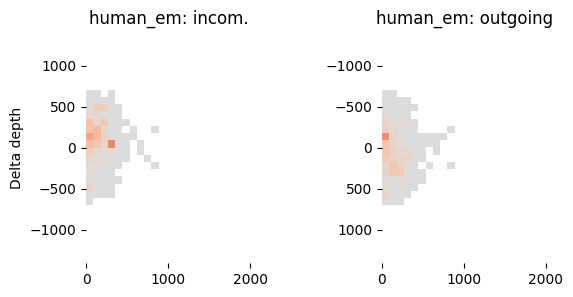

In [9]:
clim = [-.15, .15]  # For structural connectivity: [-1, 1]. Functional or MICrONS: [-0.25, 0.25]
cmap = "coolwarm"

def make_extent(df):
    delta_xz = df.columns[-1] - df.columns[-2]
    delta_y = df.index[-1] - df.index[-2]
    
    extent = [df.columns[0] - delta_xz/2, df.columns[-1] + delta_xz/2,
             df.index[-1] + delta_y/2, df.index[0] - delta_y/2]
    return extent

fig = plt.figure(figsize=(7, 3))

ax = fig.add_subplot(1, 2, 1)
img = cc_pre.sort_index().unstack("xz")
ax.imshow(img, extent=make_extent(img), clim=clim, cmap=cmap)
ax.set_ylim(sorted(ax.get_ylim()))
ax.set_frame_on(False)
ax.set_title("{0}: incom.".format(loaded))
ax.set_ylabel("Delta depth")

ax = fig.add_subplot(1, 2, 2)
img = cc_post.sort_index().unstack("xz")
ax.imshow(img, extent=make_extent(img), clim=clim, cmap=cmap)
ax.set_frame_on(False)
ax.set_title("{0}: outgoing".format(loaded))

fig.savefig("touch_count_correlations_with_nn_control.pdf".format(loaded))
# NOTE:
# For the y-axis, in BOTH cases a negative number indicates an upwards connections.
# The orientation of the y-axis is intentionally different in both plots to correctly display that!

/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/1548548926.py:6: RuntimeWarning: invalid value encountered in scalar divide
  posterior = df_in.loc[v]["count"].sum() / df_in["count"].sum()
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/1548548926.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res = dsrc.groupby(["xz", "y"]).apply(p_prior_post_fun, thresh=thresh, col=cols[i])
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/1548548926.py:6: RuntimeWarning: invalid value encountered in scalar divide
  posterior = df_in.loc[v]["count"].sum() / df_in["count"].sum()
/var/folders/py/wqmt8l2s5zb8fhrxbd_b258w0000gn/T/ipykernel_25252/1548548926.py:2

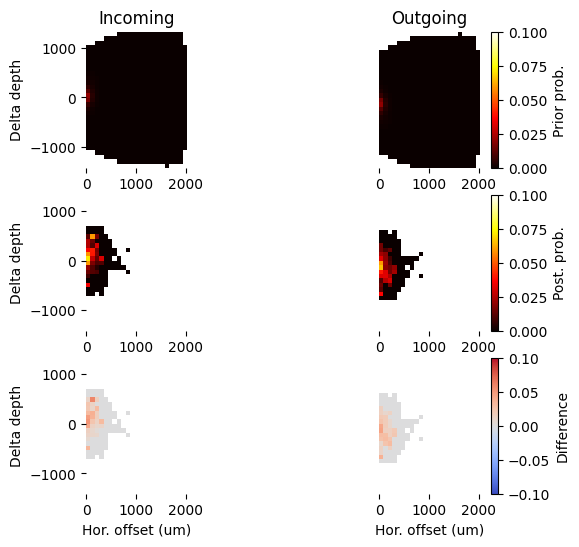

In [10]:
def p_prior_post_fun(df_in, thresh=1, col="touches_nn_post"):
    v = df_in["touches_pair"] >= thresh
    prior = df_in.loc[v]["count"].sum() / df_in["count"].sum()
    df_in = df_in.loc[v]
    v = df_in[col] >= thresh
    posterior = df_in.loc[v]["count"].sum() / df_in["count"].sum()
    return pandas.Series({
        "prior": prior,
        "posterior": posterior
    })


clim = [0.0, .1] # Structural: [0, 1]. Functional or MICrONS: [0, 0.2]
cmap = "hot"
thresh = 1

fig = plt.figure(figsize=(6.5, 6))
dfs = [df_pre, df_post]
cols = ["touches_nn_pre", "touches_nn_post"]
titles = ["Incoming", "Outgoing"]

for i in range(len(dfs)):
    dsrc = dfs[i]
    extent = make_extent(dsrc.groupby(["xz", "y"])["count"].sum().unstack("xz").iloc[:-1])
    ylim = [extent[-1], extent[-2]]
    if numpy.mod(i, 2) == 1:
        ylim = [extent[-2], extent[-1]]
    res = dsrc.groupby(["xz", "y"]).apply(p_prior_post_fun, thresh=thresh, col=cols[i])
    
    ax = fig.add_subplot(3, len(dfs), i + 1)
    img = res["prior"].sort_index().unstack("xz")
    pltimg = ax.imshow(img, extent=make_extent(img), clim=clim, cmap=cmap)
    ax.set_ylim(ylim)
    ax.set_frame_on(False)
    #ax.set_title("Thresh: {0}".format(thresh))
    if i == 0:
        ax.set_ylabel("Delta depth")
    else:
        ax.set_yticks([])
    ax.set_title(titles[i])
    if i == (len(dfs) - 1):
        plt.colorbar(pltimg, label="Prior prob.")
    # ax.set_yticklabels(numpy.abs(ax.get_yticks()).astype(int))
    
    ax = fig.add_subplot(3, len(dfs), i + len(dfs) + 1)
    img = res["posterior"].sort_index().unstack("xz")
    pltimg = ax.imshow(img, extent=make_extent(img), clim=clim, cmap=cmap)
    ax.set_ylim(ylim)
    ax.set_frame_on(False)
    if i == 0:
        ax.set_ylabel("Delta depth")
    else:
        ax.set_yticks([])
    if i == (len(dfs) - 1):
        plt.colorbar(pltimg, label="Post. prob.")
    # ax.set_yticklabels(numpy.abs(ax.get_yticks()).astype(int))
        
    ax = fig.add_subplot(3, len(dfs), i + len(dfs) + len(dfs) + 1)
    img = (res["posterior"] - res["prior"]) # / (res["prior"] + res["posterior"])
    img = img.sort_index().unstack("xz")
    pltimg = ax.imshow(img, extent=make_extent(img), clim=[-clim[1], clim[1]], cmap="coolwarm")
    ax.set_ylim(ylim)
    ax.set_frame_on(False)
    if i == 0:
        ax.set_ylabel("Delta depth")
    else:
        ax.set_yticks([])
    if i == (len(dfs) - 1):
        plt.colorbar(pltimg, label="Difference")
    ax.set_xlabel("Hor. offset (um)")
    # ax.set_yticklabels(numpy.abs(ax.get_yticks()).astype(int))

fig.savefig("prior_posterior_probabilities_control.pdf".format(loaded))

In [11]:
fn_data = "connectivity_higher_order_interactions_final.h5"

loaded = "human_em"
#loaded = "microns"
#loaded = "human_functional"
#loaded = "control"
thresh = 1
CC_pre = pandas.read_hdf(fn_data, key="{0}/{1}/pre".format(loaded, thresh))
CC_post = pandas.read_hdf(fn_data, key="{0}/{1}/post".format(loaded, thresh))

# NOTE:
# For this analysis "pre" means that we are measuring correlations of connection probabilities for different
# pre-synaptic neurons. Hence, it measures an effect on OUTGOING connectivity. This is the inverse of the
# previous analysis. I apologize.

locations = CC_pre.index.to_frame().reset_index(drop=True).drop_duplicates()

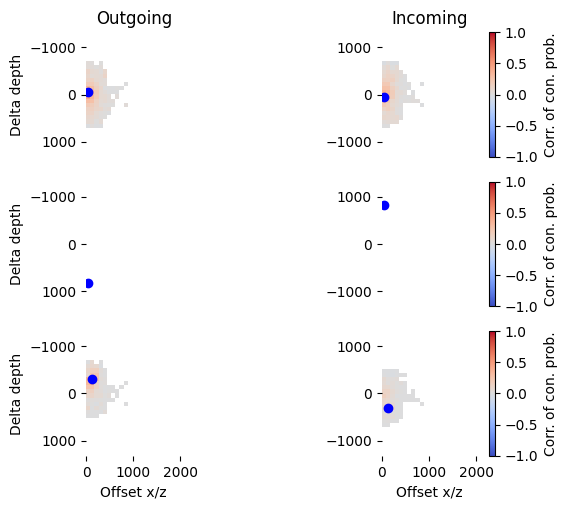

In [13]:
fig = plt.figure(figsize=(6.5, 5.5))
clim = [-1., 1.]
if loaded == "human" or loaded == "human_functional" or loaded == "control":
    location_ids = [223, 55, 150]
elif loaded == "microns" or loaded == "rat":
    location_ids = [76, 5, 118]
elif loaded == "human_em":
    location_ids = [10, 20, 30]
    
cmap="coolwarm"

pltid = 1
for _i, _loc in enumerate(location_ids): 
    ex_location = locations.iloc[_loc]
    ax = fig.add_subplot(3, 2, pltid)
    img = CC_pre[tuple(ex_location.values)].unstack("xz")
    pltimg = ax.imshow(img, extent=make_extent(img), clim=clim, cmap=cmap)
    plt.plot(ex_location["xz"], ex_location["y"], marker='o', color="blue")
    ax.set_ylabel("Delta depth")
    if pltid > 4:
        ax.set_xlabel("Offset x/z")
    if pltid < 3:
        ax.set_title("Outgoing")
    ax.set_frame_on(False)
    if _i < (len(location_ids) - 1):
        ax.set_xticks([])

    ax = fig.add_subplot(3, 2, pltid + 1)
    img = CC_post[tuple(ex_location.values)].unstack("xz")
    pltimg = ax.imshow(img, extent=make_extent(img), clim=clim, cmap=cmap)
    plt.plot(ex_location["xz"], ex_location["y"], marker='o', color="blue")
    plt.colorbar(pltimg, label="Corr. of con. prob.")
    if pltid > 4:
        ax.set_xlabel("Offset x/z")
    if pltid < 3:
        ax.set_title("Incoming")
    ax.set_frame_on(False)
    ax.set_ylim(sorted(ax.get_ylim()))
    if _i < (len(location_ids) - 1):
        ax.set_xticks([])
    pltid +=2

fig.savefig("spatial_bins_correlations_control.pdf".format(loaded))

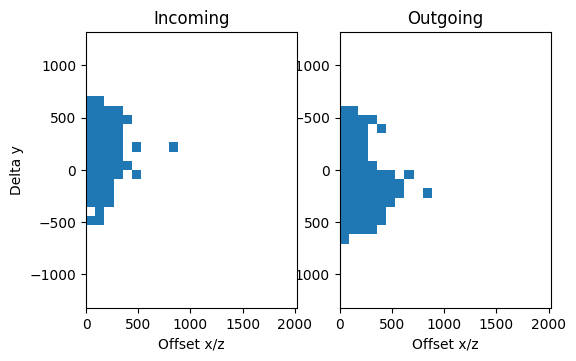

In [14]:
from sknetwork.clustering import Louvain, get_modularity
sz_thresh = 15
res_pre = 1.05
res_post = 1.05


def cluster_and_show(ax, data, res):
    L = Louvain(res).fit_predict(data).astype(float)
    Lcounts = pandas.Series(L).value_counts()
    toosmall = Lcounts.index[Lcounts.values < sz_thresh]
    L[numpy.isin(L, toosmall)] = numpy.NaN
    img = pandas.Series(L, index=CC_pre.index).unstack("xz")
    ax.imshow(img, cmap="tab20", extent=make_extent(img), interpolation="nearest")
    return L
    
fig = plt.figure(figsize=(6, 4))

ax = fig.add_subplot(1, 2, 2)
L_pre = cluster_and_show(ax, CC_pre.fillna(0).values - CC_pre.min().min(), res_pre)
#L_pre = cluster_and_show(ax, numpy.maximum(CC_pre.fillna(0).values, 0), res_pre)
ax.set_xlabel("Offset x/z")
ax.set_ylabel("Delta y")
ax.set_title("Outgoing")

ax = fig.add_subplot(1, 2, 1)
L_post = cluster_and_show(ax, CC_post.fillna(0).values - CC_post.min().min(), res_post)
#L_post = cluster_and_show(ax, numpy.maximum(CC_post.fillna(0).values, 0), res_post)
ax.set_xlabel("Offset x/z")
ax.set_title("Incoming")
ax.set_ylabel("Delta y")
ax.set_ylim(sorted(ax.get_ylim()))

fig.savefig("clustering_control.pdf".format(loaded))

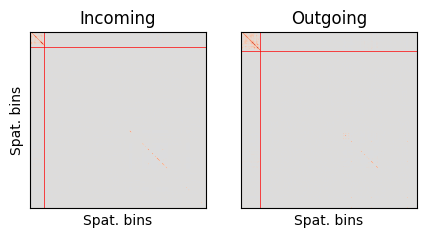

In [15]:
fig = plt.figure(figsize=(5, 2.5))

L_pre[numpy.isnan(L_pre)] = 1E5
L_post[numpy.isnan(L_post)] = 1E5

ax = fig.add_subplot(1, 2, 1)
_idx = numpy.argsort(L_post)

ax.imshow(CC_post.fillna(0).values[numpy.ix_(_idx, _idx)], clim=[-0.5, 0.5], cmap="coolwarm")
borders = numpy.nonzero(numpy.diff(L_post[_idx]) > 0)[0]
ax.set_xlim(ax.get_xlim()); ax.set_ylim(ax.get_ylim())
for b in borders:
    ax.plot(ax.get_xlim(), [b, b], color="red", lw=0.5)
    ax.plot([b, b], ax.get_ylim(), color="red", lw=0.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Spat. bins")
ax.set_ylabel("Spat. bins")
ax.set_title("Incoming")

ax = fig.add_subplot(1, 2, 2)
_idx = numpy.argsort(L_pre)

ax.imshow(CC_pre.fillna(0).values[numpy.ix_(_idx, _idx)], clim=[-0.5, 0.5], cmap="coolwarm")
borders = numpy.nonzero(numpy.diff(L_pre[_idx]) > 0)[0]
ax.set_xlim(ax.get_xlim()); ax.set_ylim(ax.get_ylim())
for b in borders:
    ax.plot(ax.get_xlim(), [b, b], color="red", lw=0.5)
    ax.plot([b, b], ax.get_ylim(), color="red", lw=0.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Spat. bins")
ax.set_title("Outgoing")

fig.savefig("Spat_bins_control.pdf".format(loaded))

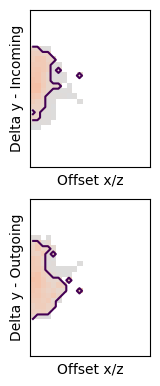

In [16]:
fig = plt.figure(figsize=(10, 4.5))

n_pre = len(numpy.unique(L_pre[L_pre < 1E3]))
n_post = len(numpy.unique(L_post[L_post < 1E3]))

layout = (2, numpy.maximum(n_pre, n_post))

for i in range(layout[1]):
    if numpy.any(L_post == i):
        cont = pandas.Series(L_post == i, index=CC_post.index).fillna(-1).astype(int).unstack("xz", fill_value=0)
        ax = fig.add_subplot(layout[0], layout[1], i + 1)
        ax.imshow(CC_post.loc[L_post == i].mean().unstack("xz"), cmap="coolwarm", clim=[-0.5, 0.5])
        ax.contour(cont.values, levels=[0.5])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylim(sorted(ax.get_ylim()))
        ax.set_xlabel("Offset x/z")
        if i == 0:
            ax.set_ylabel("Delta y - Incoming")
    if numpy.any(L_pre == i):
        cont = pandas.Series(L_pre == i, index=CC_pre.index).fillna(-1).astype(int).unstack("xz", fill_value=0)
        ax = fig.add_subplot(layout[0], layout[1], i + 1 + layout[1])
        img = ax.imshow(CC_pre.loc[L_pre == i].mean().unstack("xz"), cmap="coolwarm", clim=[-0.5, 0.5])
        ax.contour(cont.values, levels=[0.5])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel("Offset x/z")
        if i == 0:
            ax.set_ylabel("Delta y - Outgoing")

fig.savefig("Delta_y_control.pdf".format(loaded))